In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as f1
from fastf1 import plotting
from ing_theme_matplotlib import mpl_style
import mplcyberpunk

In [2]:
def convert_to_normal(time):
    if pd.isna(time):
        return time

    time_str = str(time)
    parts = time_str.split()

    days = int(parts[0])
    minutes, seconds_with_microseconds = parts[2].split(":")[1:]
    seconds, microseconds = seconds_with_microseconds.split(".")

    minutes = int(minutes)
    seconds = int(seconds)
    microseconds = int(microseconds)

    total_microseconds = (
        days * 86400000000 + minutes * 60000000 + seconds * 1000000 + microseconds
    )

    minutes, remaining_microseconds = divmod(total_microseconds, 60000000)
    seconds, microseconds = divmod(remaining_microseconds, 1000000)

    normal_time = f"{minutes:02d}:{seconds:02d}.{microseconds:06d}"
    return normal_time

In [12]:
test = f1.get_testing_session(2026,1,1)
test.load()

core           INFO 	Loading data for Pre-Season Testing - Practice 1 [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 

In [13]:
test.session_info

{'Meeting': {'Key': 1304,
  'Name': 'Pre-Season Testing',
  'OfficialName': 'FORMULA 1 ARAMCO PRE-SEASON TESTING 1 2026',
  'Location': 'Bahrain',
  'Number': 1,
  'Country': {'Key': 36, 'Code': 'BRN', 'Name': 'Bahrain'},
  'Circuit': {'Key': 63, 'ShortName': 'Sakhir'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11465,
 'Type': 'Practice',
 'Number': 1,
 'Name': 'Day 1',
 'StartDate': datetime.datetime(2026, 2, 11, 10, 0),
 'EndDate': datetime.datetime(2026, 2, 11, 19, 0),
 'GmtOffset': datetime.timedelta(seconds=10800),
 'Path': '2026/2026-02-13_Pre-Season_Testing/2026-02-11_Day_1/'}

In [14]:
test.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
1,NOR,McLaren,NaN,NaN,NaT,
3,VER,Red Bull Racing,NaN,NaN,NaT,
5,BOR,Audi,NaN,NaN,NaT,
6,HAD,Red Bull Racing,NaN,NaN,NaT,
10,GAS,Alpine,NaN,NaN,NaT,
11,PER,Cadillac,NaN,NaN,NaT,
12,ANT,Mercedes,NaN,NaN,NaT,
14,ALO,Aston Martin,NaN,NaN,NaT,
16,LEC,Ferrari,NaN,NaN,NaT,
18,STR,Aston Martin,NaN,NaN,NaT,


In [8]:
test_laps = test.laps
test_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:15:31.642000,NOR,1,NaT,1.0,1.0,0 days 00:13:09.503000,0 days 00:15:29.477000,NaT,0 days 00:01:03.044000,...,False,McLaren,0 days 00:13:09.503000,2026-02-12 07:00:16.983,671,NaN,False,,False,False
1,0 days 00:29:10.400000,NOR,1,NaT,2.0,2.0,0 days 00:27:14.649000,0 days 00:29:08.555000,NaT,0 days 00:00:50.363000,...,False,McLaren,0 days 00:27:14.649000,2026-02-12 07:14:22.129,1,NaN,False,,False,False
2,0 days 01:04:42.744000,NOR,1,NaT,3.0,3.0,0 days 01:02:20.490000,NaT,NaT,0 days 00:00:50.158000,...,True,McLaren,0 days 00:29:10.400000,2026-02-12 07:16:17.880,1,NaN,False,,False,False
3,0 days 01:06:18.931000,NOR,1,0 days 00:01:36.187000,4.0,3.0,NaT,NaT,0 days 00:00:30.695000,0 days 00:00:42.295000,...,True,McLaren,0 days 01:04:42.744000,2026-02-12 07:51:50.224,1,NaN,False,,False,True
4,0 days 01:08:27.379000,NOR,1,0 days 00:02:08.448000,5.0,3.0,NaT,0 days 01:08:25.584000,0 days 00:00:43.094000,0 days 00:00:53.085000,...,True,McLaren,0 days 01:06:18.931000,2026-02-12 07:53:26.411,1,NaN,False,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058,0 days 08:57:19.573000,BEA,87,NaT,113.0,25.0,0 days 08:54:59.102000,0 days 08:57:17.571000,NaT,0 days 00:00:45.593000,...,True,Haas F1 Team,0 days 08:50:10.294000,2026-02-12 15:37:17.774,1,NaN,False,,False,False
1059,0 days 08:59:53.392000,BEA,87,NaT,114.0,26.0,0 days 08:57:38.292000,0 days 08:59:51.970000,0 days 00:01:22.251000,0 days 00:00:44.554000,...,False,Haas F1 Team,0 days 08:57:19.573000,2026-02-12 15:44:27.053,1,NaN,False,,False,False
1060,0 days 09:02:31.156000,BEA,87,NaT,115.0,27.0,0 days 09:00:12.073000,NaT,0 days 00:01:22.330000,0 days 00:00:50.905000,...,False,Haas F1 Team,0 days 08:59:53.392000,2026-02-12 15:47:00.872,1,NaN,False,,False,False
1061,0 days 09:04:18.886000,BEA,87,0 days 00:01:47.730000,116.0,27.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:44.762000,...,False,Haas F1 Team,0 days 09:02:31.156000,2026-02-12 15:49:38.636,16,NaN,False,,False,False


In [15]:
ver_test_laps = test.laps.pick_driver("VER")
ver_test_lap_time = ver_test_laps["LapTime"]
ver_test_sec1 = ver_test_laps["Sector1Time"]
ver_test_sec2 = ver_test_laps["Sector2Time"]
ver_test_sec3 = ver_test_laps["Sector3Time"]
ver_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
58,NaT,NaT,0 days 00:00:52.581000,0 days 00:00:27.419000,204.0,203.0,258.0,171.0
59,0 days 00:01:48.950000,0 days 00:00:35.258000,0 days 00:00:48.665000,0 days 00:00:25.027000,218.0,213.0,290.0,272.0
60,0 days 00:01:44.012000,0 days 00:00:32.507000,0 days 00:00:46.733000,0 days 00:00:24.772000,222.0,220.0,298.0,293.0
61,0 days 00:01:47.032000,0 days 00:00:32.738000,0 days 00:00:45.787000,0 days 00:00:28.507000,222.0,214.0,NaN,285.0
62,NaT,NaT,0 days 00:00:48.298000,0 days 00:00:26.516000,212.0,223.0,260.0,179.0


In [16]:
fastest_lap_ver_test = ver_test_laps.pick_fastest()
tele_ver_test = fastest_lap_ver_test.get_telemetry().add_distance()
speed_ver_test = tele_ver_test.Speed
tele_ver_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,292.179996,7,10914.500288
3,293.529998,7,10813.250144
4,295.000000,8,10703.000000
5,298.629998,8,10834.284931
6,301.000000,8,10920.000000
...,...,...,...
729,280.000000,7,11131.000000
730,280.000000,7,11191.000000
731,280.000000,7,11206.000000
732,280.221428,7,11220.614256


In [17]:
lan_test_laps = test.laps.pick_driver("NOR")
lan_test_lap_time = lan_test_laps["LapTime"]
lan_test_sec1 = lan_test_laps["Sector1Time"]
lan_test_sec2 = lan_test_laps["Sector2Time"]
lan_test_sec3 = lan_test_laps["Sector3Time"]
lan_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:52.528000,0 days 00:00:29.362000,219.0,199.0,225.0,155.0
1,NaT,0 days 00:00:44.845000,0 days 00:01:01.493000,0 days 00:00:43.817000,138.0,139.0,NaN,179.0
2,NaT,NaT,0 days 00:00:48.124000,0 days 00:00:28.697000,210.0,226.0,253.0,191.0
3,NaT,0 days 00:00:44.081000,0 days 00:01:06.918000,0 days 00:00:43.100000,139.0,139.0,NaN,211.0
4,NaT,NaT,0 days 00:00:46.551000,0 days 00:00:26.182000,214.0,225.0,264.0,174.0


In [18]:
fastest_lap_lan_test = lan_test_laps.pick_fastest()
tele_lan_test = fastest_lap_lan_test.get_telemetry().add_distance()
speed_lan_test = tele_lan_test.Speed
tele_lan_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,287.035845,8,10510.498303
3,290.745522,8,10665.562832
4,292.000000,8,10718.000000
5,294.357143,8,10828.000000
6,295.000000,8,10858.000000
...,...,...,...
698,278.000000,7,11666.000000
699,278.245834,7,11663.541664
700,279.000000,7,11656.000000
701,279.000000,7,11659.300000


In [19]:
rus_test_laps = test.laps.pick_driver("RUS")
fastest_lap_rus_test = rus_test_laps.pick_fastest().LapTime
rus_test_lap_time = rus_test_laps["LapTime"]
rus_test_sec1 = rus_test_laps["Sector1Time"]
rus_test_sec2 = rus_test_laps["Sector2Time"]
rus_test_sec3 = rus_test_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_test), "which was in Lap number" ,rus_test_laps.pick_fastest().LapNumber)
rus_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:36.108000 which was in Lap number 33.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
972,NaT,NaT,0 days 00:00:51.582000,0 days 00:00:26.619000,195.0,214.0,283.0,186.0
973,0 days 00:01:41.740000,0 days 00:00:32.535000,0 days 00:00:44.571000,0 days 00:00:24.634000,221.0,237.0,301.0,291.0
974,0 days 00:01:42.617000,0 days 00:00:32.136000,0 days 00:00:45.826000,0 days 00:00:24.655000,220.0,235.0,299.0,301.0
975,0 days 00:01:40.800000,0 days 00:00:31.828000,0 days 00:00:44.617000,0 days 00:00:24.355000,220.0,242.0,295.0,300.0
976,0 days 00:01:40.391000,0 days 00:00:31.652000,0 days 00:00:44.470000,0 days 00:00:24.269000,220.0,236.0,280.0,295.0


In [20]:
fastest_lap_rus_test = rus_test_laps.pick_fastest()
tele_rus_test = fastest_lap_rus_test.get_telemetry().add_distance()
speed_rus_test = tele_rus_test.Speed
tele_rus_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,282.053573,7,11054.860763
3,284.000000,7,11137.000000
4,286.946427,7,11185.321410
5,289.000000,7,11219.000000
6,290.500001,7,11304.875073
...,...,...,...
721,280.000000,7,10869.281237
722,280.000000,7,10860.000000
723,281.866667,7,10867.466667
724,282.000000,7,10868.000000


In [21]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_test_sec1),
        "Sector1Time": ver_test_sec1,
        "Sector2Time": ver_test_sec2,
        "Sector3Time": ver_test_sec3,
        "Lap Time": ver_test_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Oscar Piastri"] * len(lan_test_sec1),
        "Sector1Time": lan_test_sec1,
        "Sector2Time": lan_test_sec2,
        "Sector3Time": lan_test_sec3,
        "Lap Time": lan_test_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_test_sec1),
        "Sector1Time": rus_test_sec1,
        "Sector2Time": rus_test_sec2,
        "Sector3Time": rus_test_sec3,
        "Lap Time": rus_test_lap_time,
    }
)




all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Max Verstappen,0 days 00:00:35.258000,0 days 00:00:48.665000,0 days 00:00:25.027000,0 days 00:01:48.950000
2,Max Verstappen,0 days 00:00:32.507000,0 days 00:00:46.733000,0 days 00:00:24.772000,0 days 00:01:44.012000
3,Max Verstappen,0 days 00:00:32.738000,0 days 00:00:45.787000,0 days 00:00:28.507000,0 days 00:01:47.032000
5,Max Verstappen,0 days 00:00:33.396000,0 days 00:00:45.974000,0 days 00:00:24.377000,0 days 00:01:43.747000
6,Max Verstappen,0 days 00:00:32.341000,0 days 00:00:45.883000,0 days 00:00:24.599000,0 days 00:01:42.823000
...,...,...,...,...,...
242,George Russell,0 days 00:00:31.575000,0 days 00:00:44.537000,0 days 00:00:24.438000,0 days 00:01:40.550000
243,George Russell,0 days 00:00:31.671000,0 days 00:00:44.105000,0 days 00:00:24.210000,0 days 00:01:39.986000
244,George Russell,0 days 00:00:32.082000,0 days 00:00:44.479000,0 days 00:00:24.438000,0 days 00:01:40.999000
245,George Russell,0 days 00:00:31.757000,0 days 00:00:45.032000,0 days 00:00:24.672000,0 days 00:01:41.461000


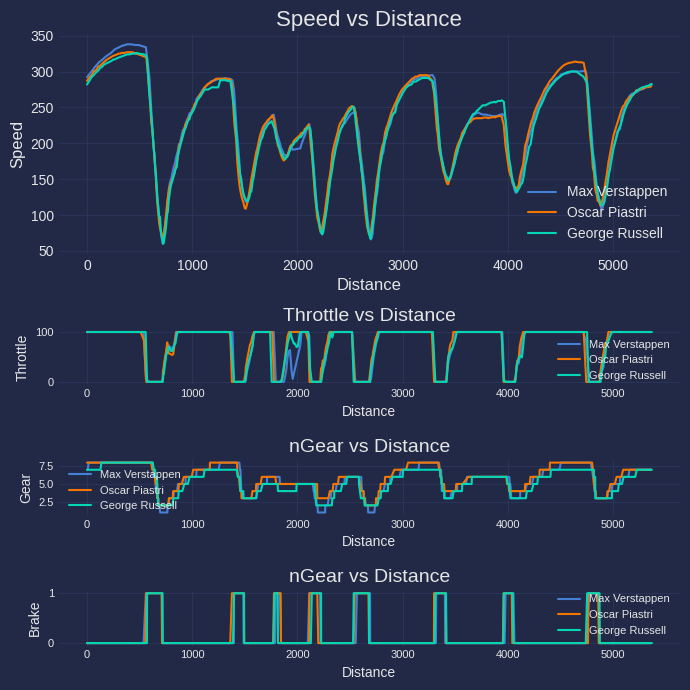

In [22]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = test.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_ver_test.Distance, tele_ver_test.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lan_test.Distance, tele_lan_test.Speed, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[0].plot(
    tele_rus_test.Distance, tele_rus_test.Speed, label="George Russell", color=get_driver_color("RUS")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_ver_test.Distance, tele_ver_test.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lan_test.Distance, tele_lan_test.Throttle, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[1].plot(
    tele_rus_test.Distance, tele_rus_test.Throttle, label="George Russell", color=get_driver_color("RUS")
)
ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_ver_test.Distance, tele_ver_test.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lan_test.Distance, tele_lan_test.nGear, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[2].plot(
    tele_rus_test.Distance, tele_rus_test.nGear, label="George Russell", color=get_driver_color("RUS")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_ver_test.Distance, tele_ver_test.Brake, label="Max Verstappen", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lan_test.Distance, tele_lan_test.Brake, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[3].plot(
    tele_rus_test.Distance, tele_rus_test.Brake, label="George Russell", color=get_driver_color("RUS")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [23]:
plotting.setup_mpl()

In [28]:
laps_rus = test_laps.pick_driver("RUS")
laps_pia = test_laps.pick_driver("NOR")

fastest_rus = laps_rus.pick_fastest().get_telemetry().add_distance()
fastest_pia = laps_pia.pick_fastest().get_telemetry().add_distance()

fastest_rus["Driver"] = "RUS"
fastest_pia["Driver"] = "PIA"
telemetry = pd.concat([fastest_rus, fastest_pia])

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [29]:
num_minisectors = 25
total_distance = total_distance = max(telemetry['Distance'])
minisector_length = total_distance / num_minisectors
minisectors = [0]
for i in range(0, (num_minisectors - 1)):
    minisectors.append(minisector_length * (i + 1))
telemetry['Minisector'] = telemetry['Distance'].apply(
    lambda dist: (
        int((dist // minisector_length) + 1)
    )
)

In [30]:
average_speed = telemetry.groupby(['Minisector', 'Driver'])['Speed'].mean().reset_index()
average_speed

,Minisector,Driver,Speed
0,1,PIA,314.030451
1,1,RUS,299.239180
2,2,PIA,326.275105
3,2,RUS,321.742246
4,3,PIA,278.031931
5,3,RUS,289.627473
6,4,PIA,108.830021
7,4,RUS,111.348701
8,5,PIA,227.876572
9,5,RUS,230.856655


In [31]:
fastest_driver = average_speed.loc[average_speed.groupby(['Minisector'])['Speed'].idxmax()]

fastest_driver = fastest_driver[['Minisector', 'Driver']].rename(columns={'Driver': 'Fastest_driver'})


In [32]:
telemetry = telemetry.merge(fastest_driver, on=['Minisector'])

telemetry = telemetry.sort_values(by=['Distance'])

telemetry.loc[telemetry['Fastest_driver'] == 'RUS', 'Fastest_driver_int'] = 1
telemetry.loc[telemetry['Fastest_driver'] == 'PIA', 'Fastest_driver_int'] = 2

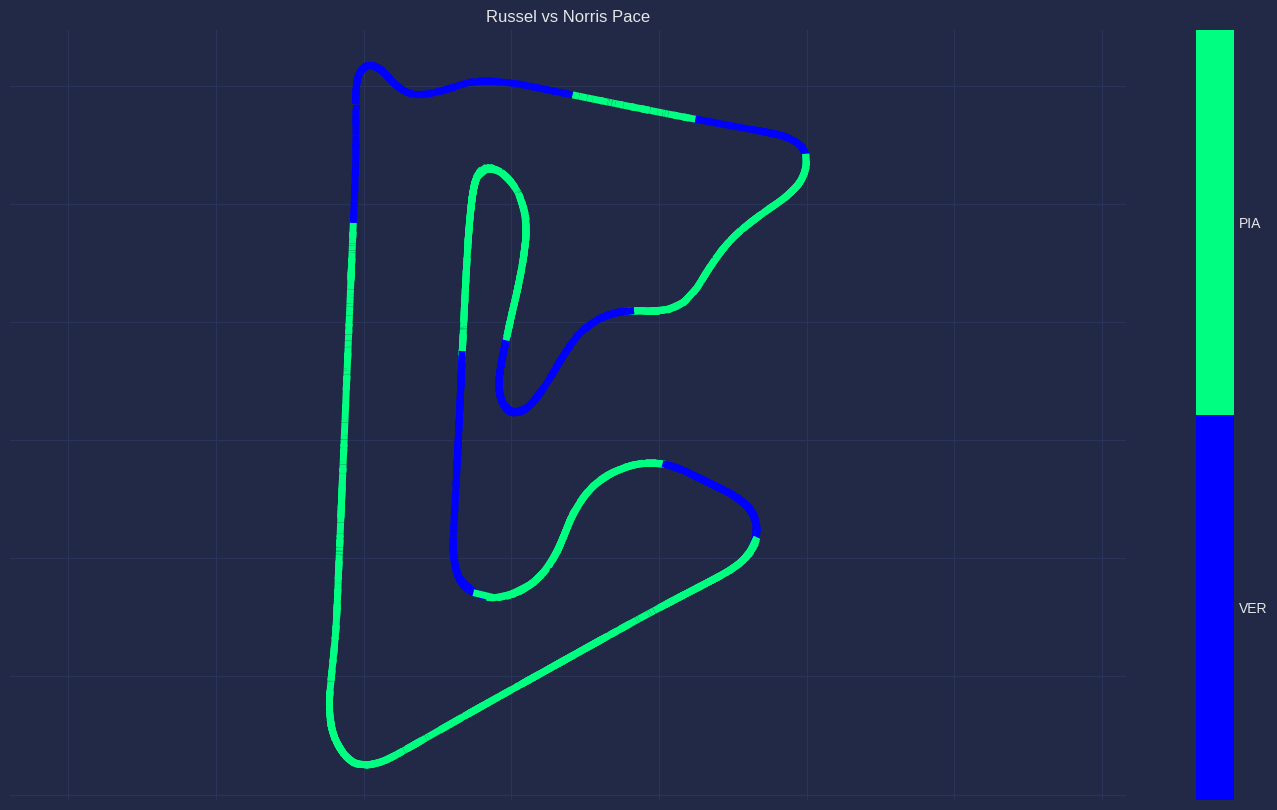

In [35]:
x = np.array(telemetry['X'].values)
y = np.array(telemetry['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fastest_driver_array = telemetry['Fastest_driver_int'].to_numpy().astype(float)

cmap = plt.get_cmap('winter', 2)  # Create a colormap with 2 colors
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(fastest_driver_array)
lc_comp.set_linewidth(5)

plt.rcParams['figure.figsize'] = [18, 10]
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

cbar = plt.colorbar(mappable=lc_comp, boundaries=[1, 2, 3])
cbar.set_ticks([1.5, 2.5])
cbar.set_ticklabels(['VER', 'PIA'])
plt.title("Russel vs Norris Pace")
plt.show()
